# Arabic Dialect Detection — Stacking Transformer Model
## Replication of Saleh et al. (2025) on the IADD Corpus

**Project:** Deep Learning Approach to Pan-Arabic Dialect Detection  
**Authors (original paper):** Saleh, AlMohimeed, Hassan, Ibrahim, Alsamhi, Hassan, Mostafa  
**Reference:** *Advancing Arabic Dialect Detection with Hybrid Stacked Transformer Models*, Frontiers in Human Neuroscience, 2025  

---

### What this notebook does

This notebook implements the **full model comparison pipeline** from Saleh et al. (2025):

| Level | Models | Embeddings |
|-------|--------|-----------|
| Baseline DL | LSTM · GRU · CNN | Word2Vec CBOW |
| Single Transformers | AraBERT · Dialectal-Arabic-XLM-R-Base | Contextual |
| **Proposed (Stacking)** | **Bert-Base-Arabertv02 + XLM-R → Random Forest** | **Contextual class probs** |

**Architecture logic (two-level stacking):**
- **Level 1 (Base models):** Two transformer models are independently fine-tuned. Each produces a probability vector over dialect classes for every input.
- **Level 2 (Meta-learner):** The concatenated probability vectors from both transformers become input features to a Random Forest classifier, which makes the final dialect prediction.

**Dataset:** IADD — 135,804 Arabic texts from 5 dialectal regions (LEV, MGH, GLF, EGY, general), excluding IRQ (<1%, only 216 samples).

---
> **Runtime note:** Full transformer fine-tuning requires a GPU. In Google Colab, go to `Runtime → Change runtime type → GPU (T4 or A100)`.


## 1. Installation

All required packages for NLP preprocessing, deep learning, transformer fine-tuning, and evaluation.


In [ ]:
# 1. INSTALL DEPENDENCIES (The "Total Refresh" version)
# We upgrade the core stack together to prevent version mismatch
!pip install -q -U torch transformers accelerate
!pip install -q datasets
!pip install -q gensim
!pip install -q arabert
!pip install -q camel-tools
!pip install -q farasa
!pip install -q pyarabic
!pip install -q scikit-learn
!pip install -q seaborn
!pip install -q tqdm

print("Environment synchronized. RESTART RUNTIME NOW.")

## 2. Imports

In [1]:
import os
import re
import json
import random
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm.auto import tqdm

# ── Scikit-learn ──
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

# ── PyTorch ──
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# ── HuggingFace Transformers ──
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer,
    EarlyStoppingCallback
)
from datasets import Dataset as HFDataset

# ── Gensim (Word2Vec / CBOW) ──
from gensim.models import Word2Vec

# ── Arabic NLP ──
import pyarabic.araby as araby      # Arabic character utilities

warnings.filterwarnings("ignore")

# ── Reproducibility ──
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")


2026-05-05 07:39:25.303961: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777966765.484463     194 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777966765.536251     194 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777966765.963231     194 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777966765.963263     194 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777966765.963266     194 computation_placer.cc:177] computation placer alr

Device: cuda
GPU: Tesla T4


## 3. Global Configuration

All hyperparameters and model identifiers are declared here so you can tune them from one place.


In [2]:
# ─── Data ───────────────────────────────────────────────────────
DATA_PATH     = "IADD.json"   # Update if loading from Drive
TRAIN_RATIO   = 0.75          # 75 / 25 split (Saleh et al., §3.3)
EXCLUDE_LABEL = "IRQ"         # Too few samples (<1%) — excluded per paper

# ─── DL model parameters (Table 3, Saleh et al. 2025) ───────────
DL_CONFIG = {
    "embed_dim"   : 128,   # Word2Vec CBOW dimension
    "max_len"     : 100,   # Sequence truncation length
    "vocab_size"  : 50_000,
    "num_nodes"   : 200,   # LSTM / GRU hidden size
    "cnn_filters" : 128,
    "kernel_size" : 4,
    "dropout"     : 0.2,
    "lr"          : 1e-3,
    "batch_size"  : 64,
    "epochs"      : 10,
}

# ─── Transformer parameters (Table 3, Saleh et al. 2025) ────────
TRANSFORMER_CONFIG = {
    "max_len"      : 128,
    "batch_size"   : 16,
    "epochs"       : 5,
    "lr"           : 2e-5,
    "warmup_steps" : 500,
    "weight_decay" : 0.01,
    "dropout"      : 0.1,
}

# ─── HuggingFace model identifiers ──────────────────────────────
# AraBERT v02 — BERT pre-trained on 77GB Arabic text (Antoun et al., 2020)
ARABERT_MODEL_NAME  = "aubmindlab/bert-base-arabertv02"

# Dialectal Arabic XLM-R Base — XLM-R fine-tuned on multi-dialectal Arabic
# (Khalifa et al., 2021; Qwaider & Abu Kwaik, 2022)
# NOTE: If this ID is unavailable, use "CAMeL-Lab/camelbert-da" as a drop-in alternative
XLMR_MODEL_NAME     = "CAMeL-Lab/bert-base-arabic-camelbert-da"

# ─── Labels ─────────────────────────────────────────────────────
LABEL_NAMES = ["EGY", "GLF", "LEV", "MGH", "general"]   # 5 classes
NUM_CLASSES  = len(LABEL_NAMES)

print("Configuration loaded.")
print(f"Labels: {LABEL_NAMES}")


Configuration loaded.
Labels: ['EGY', 'GLF', 'LEV', 'MGH', 'general']


## 4. Mount Google Drive

Mount Drive to load the IADD dataset and to save model checkpoints so they persist after the session ends.
IN KAGGLE THIS IS DISABLED!

In [3]:
from google.colab import drive
#drive.mount('/content/drive')

# ── Point to your dataset location ──────────────────────────────
# Option A: dataset is in Colab's local storage (uploaded directly)
DATA_PATH = "/kaggle/input/datasets/aymankassan/iadd-dl/IADD.json"

# Option B: dataset is in Google Drive — uncomment and update the path:
# DATA_PATH = "/content/drive/MyDrive/YOUR_FOLDER/IADD.json"

# ── Create output directory on Drive for checkpoints & results ──
OUTPUT_DIR = "/kaggle/working/arabic_dialect_stacking"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR}")


Output directory: /kaggle/working/arabic_dialect_stacking


## 5. Data Loading & Exploratory Data Analysis

The IADD corpus (Zahir, 2022) is a 135,804-entry JSON file. Each record has four fields:
- `Sentence` — the raw Arabic text
- `Region`   — dialectal region label (LEV, MGH, GLF, EGY, IRQ, general)
- `Country`  — country of origin (if available)
- `DataSource` — originating corpus (DART, SHAMI, TSAC, PADIC, AOC)


In [4]:
# ─── Load JSON ──────────────────────────────────────────────────
with open(DATA_PATH, "r", encoding="utf-8") as f:
    raw = json.load(f)

df = pd.DataFrame(raw)
print(f"Total records  : {len(df):,}")
print(f"Columns        : {list(df.columns)}")
print()
print(df.head(3))


Total records  : 135,804
Columns        : ['Sentence', 'Region', 'DataSource', 'Country']

                                            Sentence Region DataSource Country
0   : وش فيك تسألني إذا كنت غالي؟  غالي وتسوى من ...    GLF       DART      NA
1  روان بن حسين مستحيل ما ادز شي بسناب  حتى لو ما...    GLF       DART      NA
2   : ما نسيتك بالدعا والأرض جفاف، وشلون أبنساك و...    GLF       DART      NA


Class distribution (full dataset):
Region
LEV        87573
MGH        33996
GLF         6682
EGY         4837
general     2500
IRQ          216

Classes: ['LEV', 'MGH', 'GLF', 'EGY', 'general', 'IRQ']


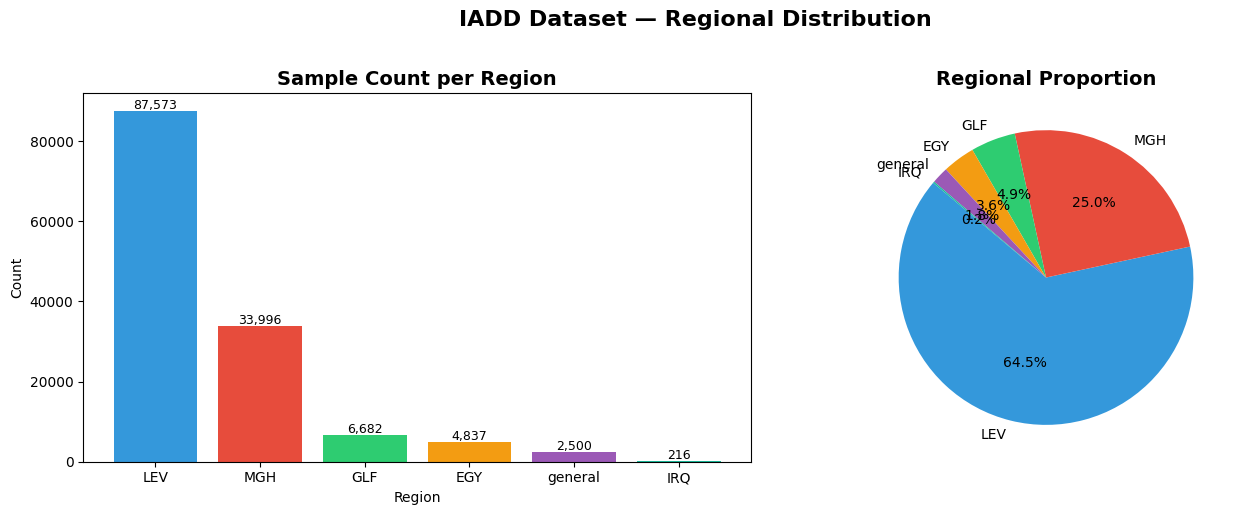


NOTE: IRQ has only 216 samples (<1%) and will be excluded.


In [5]:
# ─── Class distribution ─────────────────────────────────────────
dist = df["Region"].value_counts()
print("Class distribution (full dataset):")
print(dist.to_string())
print(f"\nClasses: {dist.index.tolist()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
axes[0].bar(dist.index, dist.values,
            color=["#3498db","#e74c3c","#2ecc71","#f39c12","#9b59b6","#1abc9c"])
axes[0].set_title("Sample Count per Region", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Region")
axes[0].set_ylabel("Count")
for i, v in enumerate(dist.values):
    axes[0].text(i, v + 500, f"{v:,}", ha="center", fontsize=9)

# Pie chart
axes[1].pie(dist.values, labels=dist.index, autopct="%1.1f%%", startangle=140,
            colors=["#3498db","#e74c3c","#2ecc71","#f39c12","#9b59b6","#1abc9c"])
axes[1].set_title("Regional Proportion", fontsize=14, fontweight="bold")

plt.suptitle("IADD Dataset — Regional Distribution", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/01_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print()
print("NOTE: IRQ has only 216 samples (<1%) and will be excluded.")


Text statistics per region:
        word_count               char_count               
              mean median    std       mean median     std
Region                                                    
EGY          23.98   13.0  40.40     130.75   67.0  224.37
GLF          15.72   10.0  93.11      89.24   52.0  756.69
IRQ          12.68   12.0   7.07      67.39   63.0   38.17
LEV          13.01    9.0  15.09      66.44   47.0   78.18
MGH           7.62    5.0  22.98      39.95   25.0  132.60
general       9.00    6.0  10.53      49.95   32.0   59.01


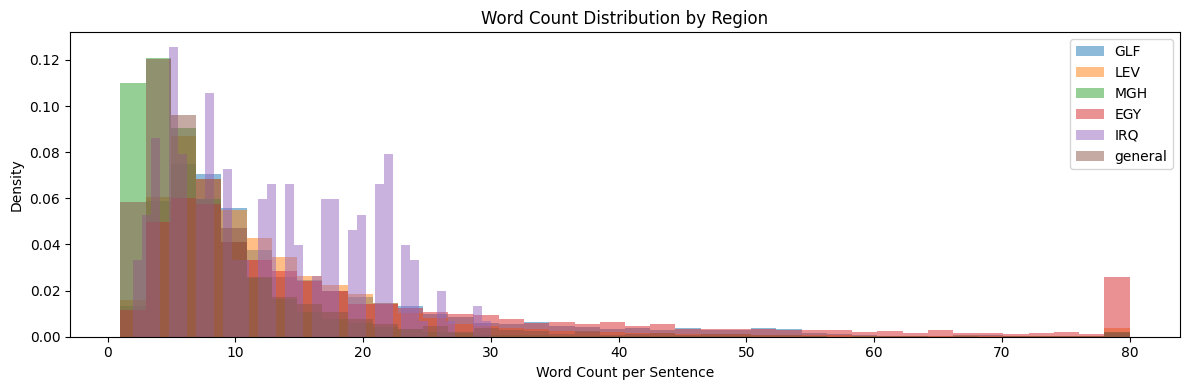

In [6]:
# ─── Text statistics per region ─────────────────────────────────
df["word_count"] = df["Sentence"].str.split().str.len()
df["char_count"] = df["Sentence"].str.len()

stats = df.groupby("Region")[["word_count", "char_count"]].agg(["mean", "median", "std"]).round(2)
print("Text statistics per region:")
print(stats.to_string())

# Word count distribution
fig, ax = plt.subplots(figsize=(12, 4))
for region in df["Region"].unique():
    subset = df[df["Region"] == region]["word_count"].clip(0, 80)
    ax.hist(subset, bins=40, alpha=0.5, label=region, density=True)
ax.set_xlabel("Word Count per Sentence")
ax.set_ylabel("Density")
ax.set_title("Word Count Distribution by Region")
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/02_word_count_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


In [7]:
# ─── Data sources per region ────────────────────────────────────
cross = pd.crosstab(df["Region"], df["DataSource"])
cross["TOTAL"] = cross.sum(axis=1)
print("Records per Region × DataSource:")
print(cross.to_string())


Records per Region × DataSource:
DataSource   AOC  DART  PADIC  SHAMI   TSAC  TOTAL
Region                                            
EGY         4414   423      0      0      0   4837
GLF         6259   423      0      0      0   6682
IRQ            9   207      0      0      0    216
LEV         6503   397  14426  66247      0  87573
MGH           28   331  21639      0  11998  33996
general     2500     0      0      0      0   2500


## 6. Text Preprocessing

Following Saleh et al. (2025) §3.2, preprocessing consists of four main stages:

1. **Tokenization** — splitting text into word tokens  
2. **Data cleaning** — normalisation, punctuation and special character removal  
3. **Stop-word removal** — removing MSA stop words while preserving dialect-specific ones  
4. **Stemming** — reducing words to their morphological root using Arabic-specific algorithms  

Additionally, following the IADD paper (Zahir, 2022), we apply:
- Letter normalisation (alef/ya/ta-marbuta variants)
- Diacritics removal
- Elongation removal (تشديد/tashdid)
- Latin character removal


In [8]:
import re
import pyarabic.araby as araby

# ─── Arabic stop words (MSA, from a standard list) ──────────────
MSA_STOPWORDS = {
    "من","إلى","عن","على","في","مع","هذا","هذه","ذلك","تلك",
    "التي","الذي","اللذين","اللتان","كان","كانت","يكون","تكون",
    "هو","هي","هم","هن","أنا","أنت","أنتم","نحن","لكن","أو",
    "لا","ما","مما","وما","وهو","وهي","وهم","أن","إن","لأن",
    "لكي","حتى","إذا","إذ","لو","لقد","قد","بعد","قبل","عند",
    "منذ","خلال","حول","بين","وبين","بسبب","رغم","مثل","أيضا"
}

def preprocess_arabic(text: str, remove_stopwords: bool = True) -> str:
    '''
    Full Arabic text preprocessing pipeline.

    Steps:
      1. Remove URLs and mentions
      2. Remove Latin characters and digits
      3. Normalise Arabic letters (alef, ya, ta-marbuta variants)
      4. Remove diacritics (tashkeel)
      5. Remove elongation (tatweel)
      6. Remove punctuation and special characters
      7. Tokenise (whitespace split)
      8. Remove MSA stop words (optional)
      9. Rejoin tokens
    '''
    if not isinstance(text, str) or text.strip() == "":
        return ""

    # 1. Remove URLs and @mentions
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)

    # 2. Remove Latin characters and digits
    text = re.sub(r"[a-zA-Z0-9]", " ", text)

    # 3. Arabic letter normalisation using pyarabic
    text = araby.strip_tatweel(text)        # elongation
    text = araby.normalize_ligature(text)   # lam-alef ligatures
    # Alef variants → bare alef
    text = re.sub(r"[أإآ]", "ا", text)
    # Ya variants → dotless ya
    text = re.sub(r"ى", "ي", text)
    # Ta-marbuta → ha
    text = re.sub(r"ة", "ه", text)

    # 4. Remove diacritics (tashkeel)
    text = araby.strip_tashkeel(text)

    # 5. Remove punctuation and special characters
    # Keep Arabic letters and spaces only
    text = re.sub(r"[^\u0600-\u06FF\s]", " ", text)

    # 6. Tokenise
    tokens = text.split()

    # 7. Remove MSA stop words (dialect-specific stop words are retained)
    if remove_stopwords:
        tokens = [t for t in tokens if t not in MSA_STOPWORDS]

    # 8. Remove very short tokens (length < 2)
    tokens = [t for t in tokens if len(t) >= 2]

    return " ".join(tokens)


# ─── Quick sanity check ──────────────────────────────────────────
sample = df["Sentence"].iloc[0]
print("Original :", sample[:120])
print("Processed:", preprocess_arabic(sample)[:120])


Original :  : وش فيك تسألني إذا كنت غالي؟  غالي وتسوى من غلااتك عيوني   كل  ما تمر  ايامنا  والليالي  يزداد  حبك  بي ويكثر  جنوني 
Processed: وش فيك تسالني اذا كنت غالي؟ غالي وتسوي غلااتك عيوني كل تمر ايامنا والليالي يزداد حبك بي ويكثر جنوني


In [9]:
from tqdm.auto import tqdm

# Initialize tqdm for pandas
tqdm.pandas()

# ─── Apply preprocessing to the full dataset ────────────────────
print("Preprocessing all sentences... (this may take a few minutes)")
df["clean_text"] = df["Sentence"].progress_apply(
    lambda x: preprocess_arabic(x, remove_stopwords=True)
)

# Drop rows where preprocessing produced an empty string
n_before = len(df)
df = df[df["clean_text"].str.strip() != ""].copy()
print(f"Dropped {n_before - len(df):,} empty rows after preprocessing.")
print(f"Remaining: {len(df):,} rows")


Preprocessing all sentences... (this may take a few minutes)


  0%|          | 0/135804 [00:00<?, ?it/s]

Dropped 6,582 empty rows after preprocessing.
Remaining: 129,222 rows


## 7. Data Preparation

### 7.1 — Exclude IRQ class  
The Iraqi dialect has only 216 samples (<1% of the dataset). Including it would severely harm model generalisation and introduce class imbalance. Saleh et al. (2025) exclude it in their experiments (see Table 2).

### 7.2 — Label encoding  
Region labels are encoded as integers for PyTorch compatibility.

### 7.3 — Stratified train/test split  
A 75/25 stratified split is used (Saleh et al., §3.3), preserving the proportion of each class in both sets.


In [10]:
# ─── Filter out IRQ ─────────────────────────────────────────────
df_filtered = df[df["Region"] != EXCLUDE_LABEL].copy()
print(f"After excluding IRQ: {len(df_filtered):,} records")
print(df_filtered["Region"].value_counts())


After excluding IRQ: 129,006 records
Region
LEV        87529
MGH        27460
GLF         6682
EGY         4835
general     2500
Name: count, dtype: int64


In [11]:
# ─── Label encoding ─────────────────────────────────────────────
le = LabelEncoder()
df_filtered["label"] = le.fit_transform(df_filtered["Region"])
label_map = {name: idx for idx, name in enumerate(le.classes_)}
id2label  = {idx: name for name, idx in label_map.items()}
NUM_CLASSES = len(le.classes_)

print(f"Label mapping: {label_map}")
print(f"Number of classes: {NUM_CLASSES}")


Label mapping: {'EGY': 0, 'GLF': 1, 'LEV': 2, 'MGH': 3, 'general': 4}
Number of classes: 5


In [12]:
# ─── Stratified 75/25 train/test split ──────────────────────────
X = df_filtered["clean_text"].tolist()
y = df_filtered["label"].tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=(1 - TRAIN_RATIO),
    stratify=y,
    random_state=SEED
)

print(f"Training set   : {len(X_train):,}")
print(f"Testing set    : {len(X_test):,}")
print()

# Class distribution in each split
train_dist = Counter(y_train)
test_dist  = Counter(y_test)
print("Train class counts:", {id2label[k]: v for k, v in sorted(train_dist.items())})
print("Test  class counts:", {id2label[k]: v for k, v in sorted(test_dist.items())})


Training set   : 96,754
Testing set    : 32,252

Train class counts: {'EGY': 3626, 'GLF': 5012, 'LEV': 65646, 'MGH': 20595, 'general': 1875}
Test  class counts: {'EGY': 1209, 'GLF': 1670, 'LEV': 21883, 'MGH': 6865, 'general': 625}


## 8. Evaluation Utilities

All models are evaluated with the same four metrics used in Saleh et al. (2025) §3.7:
- **Accuracy** — overall correct predictions
- **Precision** — weighted average across classes
- **Recall** — weighted average across classes
- **F1-score** — harmonic mean of Precision and Recall

Additionally, we produce a **Confusion Matrix** for each model.


In [14]:
# ─── Global results storage ─────────────────────────────────────
all_results = {}   # { model_name: {"accuracy": ..., "precision": ..., ... } }

def evaluate_model(model_name: str, y_true, y_pred, verbose=True):
    """
    Compute accuracy, macro-weighted precision, recall, F1-score.
    Store results in the global all_results dict.
    """
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec  = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1   = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    all_results[model_name] = {
        "Accuracy" : round(acc  * 100, 3),
        "Precision": round(prec * 100, 3),
        "Recall"   : round(rec  * 100, 3),
        "F1-score" : round(f1   * 100, 3),
    }

    if verbose:
        print(f"\n{'='*50}")
        print(f"  Model: {model_name}")
        print(f"{'='*50}")
        print(f"  Accuracy : {acc*100:.3f}%")
        print(f"  Precision: {prec*100:.3f}%")
        print(f"  Recall   : {rec*100:.3f}%")
        print(f"  F1-score : {f1*100:.3f}%")
        print()
        print(classification_report(y_true, y_pred,
                                    target_names=[id2label[i] for i in range(NUM_CLASSES)],
                                    zero_division=0))
    return all_results[model_name]


def plot_confusion_matrix(model_name: str, y_true, y_pred):
    """Plot and save a confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    labels = [id2label[i] for i in range(NUM_CLASSES)]

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_xlabel("Predicted Label", fontsize=12)
    ax.set_ylabel("True Label", fontsize=12)
    ax.set_title(f"Confusion Matrix — {model_name}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    safe_name = model_name.replace(" ", "_").replace("/", "-")
    plt.savefig(f"{OUTPUT_DIR}/cm_{safe_name}.png", dpi=150, bbox_inches="tight")
    plt.show()

print("Evaluation utilities ready.")


Evaluation utilities ready.


## 9. Word2Vec CBOW Embeddings (for Baseline DL Models)

Classical deep learning models (LSTM, GRU, CNN) use **CBOW (Continuous Bag-of-Words)** word2vec embeddings to represent text numerically.

CBOW predicts a target word from its surrounding context window. Once trained, the embedding matrix maps each word to a dense vector that encodes semantic similarity — words used in similar contexts end up close in embedding space.

The embedding model is trained on the *training set only* (to prevent data leakage) and then used to embed both train and test sequences.


In [15]:
# ─── Tokenise training corpus ────────────────────────────────────
train_tokenised = [text.split() for text in X_train]

# ─── Train Word2Vec CBOW ─────────────────────────────────────────
# sg=0 → CBOW (as used in the paper); sg=1 → Skip-gram
# window=5 → context window size
# min_count=2 → ignore words appearing fewer than 2 times
print("Training Word2Vec CBOW embeddings...")
w2v_model = Word2Vec(
    sentences  = train_tokenised,
    vector_size= DL_CONFIG["embed_dim"],   # 128-dimensional vectors
    window     = 5,
    min_count  = 2,
    sg         = 0,                         # 0 = CBOW
    workers    = 4,
    seed       = SEED,
    epochs     = 10
)
print(f"Vocabulary size: {len(w2v_model.wv):,} words")
print(f"Embedding dim  : {DL_CONFIG['embed_dim']}")

# ─── Build embedding matrix for the model's nn.Embedding layer ───
# Special tokens: 0 = <PAD>, 1 = <UNK>
VOCAB = {word: idx + 2 for idx, word in enumerate(w2v_model.wv.index_to_key)}
VOCAB["<PAD>"] = 0
VOCAB["<UNK>"] = 1
VOCAB_SIZE = len(VOCAB)

embedding_matrix = np.zeros((VOCAB_SIZE, DL_CONFIG["embed_dim"]))
for word, idx in VOCAB.items():
    if word in w2v_model.wv:
        embedding_matrix[idx] = w2v_model.wv[word]
# <UNK> gets a random initialisation
embedding_matrix[1] = np.random.normal(0, 0.1, DL_CONFIG["embed_dim"])

print(f"Embedding matrix shape: {embedding_matrix.shape}")


Training Word2Vec CBOW embeddings...
Vocabulary size: 58,931 words
Embedding dim  : 128
Embedding matrix shape: (58933, 128)


In [16]:
# ─── Helper: text → padded integer sequence ──────────────────────
def text_to_sequence(text: str, vocab: dict, max_len: int) -> list:
    """
    Convert a preprocessed Arabic string to a zero-padded integer sequence.
    Tokens not in vocabulary are mapped to <UNK> (index 1).
    """
    tokens = text.split()[:max_len]
    ids    = [vocab.get(t, 1) for t in tokens]        # 1 = <UNK>
    pad    = max_len - len(ids)
    return ids + [0] * pad                             # 0 = <PAD>

MAX_LEN = DL_CONFIG["max_len"]

X_train_seq = np.array([text_to_sequence(t, VOCAB, MAX_LEN) for t in X_train])
X_test_seq  = np.array([text_to_sequence(t, VOCAB, MAX_LEN) for t in X_test])
y_train_arr = np.array(y_train)
y_test_arr  = np.array(y_test)

print(f"Train sequences: {X_train_seq.shape}")
print(f"Test  sequences: {X_test_seq.shape}")


Train sequences: (96754, 100)
Test  sequences: (32252, 100)


## 10. PyTorch Dataset & DataLoader

In [18]:
class SequenceDataset(Dataset):
    """
    PyTorch Dataset for integer-encoded text sequences.
    Used by LSTM, GRU, and CNN models.
    """
    def __init__(self, sequences: np.ndarray, labels: np.ndarray):
        self.X = torch.LongTensor(sequences)
        self.y = torch.LongTensor(labels)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def make_loaders(X_tr, y_tr, X_te, y_te, batch_size=64):
    train_ds = SequenceDataset(X_tr, y_tr)
    test_ds  = SequenceDataset(X_te, y_te)
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=2)
    test_dl  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=2)
    return train_dl, test_dl

train_dl, test_dl = make_loaders(
    X_train_seq, y_train_arr,
    X_test_seq,  y_test_arr,
    DL_CONFIG["batch_size"]
)
print(f"Train batches: {len(train_dl)}")
print(f"Test  batches: {len(test_dl)}")


Train batches: 1512
Test  batches: 504


## 11. Baseline Deep Learning Architectures

### Architecture overview (Table 3, Saleh et al. 2025)

All three baseline models share the same embedding layer (pretrained CBOW Word2Vec) and the same output head. They differ in how they process the sequence of word vectors.

| Component | LSTM | GRU | CNN |
|-----------|------|-----|-----|
| Input | Embedded sequence | Embedded sequence | Embedded sequence |
| Core layer | BiLSTM (200 hidden) | BiGRU (200 hidden) | 1D Conv (128 filters, kernel=4) |
| Dropout | 0.2 | 0.2 | 0.2 |
| Output | FC → softmax | FC → softmax | GlobalMaxPool → FC → softmax |

**Why pre-trained embeddings?** Fine-tuning word vectors on a small in-domain corpus rather than random initialisation significantly boosts convergence speed and final accuracy for Arabic text tasks, particularly when the vocabulary is rich and morphologically complex.


In [19]:
def make_embedding_layer(embedding_matrix: np.ndarray, trainable: bool = False):
    """
    Create a nn.Embedding layer pre-loaded with Word2Vec weights.
    trainable=False freezes the vectors (faster, avoids overfitting on small data).
    trainable=True allows the embeddings to be updated during training.
    """
    vocab_size, embed_dim = embedding_matrix.shape
    emb = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
    emb.weight = nn.Parameter(torch.FloatTensor(embedding_matrix))
    if not trainable:
        emb.weight.requires_grad = False
    return emb


# ─── LSTM Model ──────────────────────────────────────────────────
class LSTMClassifier(nn.Module):
    """
    Bidirectional LSTM for dialect classification.

    Architecture:
      Embedding (CBOW pretrained)
      → BiLSTM (hidden_size=200, 1 layer)
      → Dropout (0.2)
      → Linear (400 → num_classes)

    Bidirectional LSTM processes the sequence both left-to-right and
    right-to-left, concatenating both hidden states, which gives the
    model access to full sentence context at every position.
    """
    def __init__(self, embedding_matrix, num_classes,
                 hidden_size=200, dropout=0.2):
        super().__init__()
        embed_dim = embedding_matrix.shape[1]
        self.embedding = make_embedding_layer(embedding_matrix, trainable=True)
        self.lstm = nn.LSTM(
            embed_dim, hidden_size,
            batch_first=True, bidirectional=True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size * 2, num_classes)   # *2 for bidirectional

    def forward(self, x):
        emb  = self.dropout(self.embedding(x))
        out, (h_n, _) = self.lstm(emb)
        # Concatenate final forward and backward hidden states
        h = torch.cat([h_n[0], h_n[1]], dim=1)
        return self.fc(self.dropout(h))


# ─── GRU Model ───────────────────────────────────────────────────
class GRUClassifier(nn.Module):
    """
    Bidirectional GRU for dialect classification.

    GRU is a lighter alternative to LSTM — it uses two gates (update, reset)
    instead of three (forget, input, output), reducing parameter count while
    retaining most of LSTM's ability to model long-range dependencies.
    """
    def __init__(self, embedding_matrix, num_classes,
                 hidden_size=200, dropout=0.2):
        super().__init__()
        embed_dim = embedding_matrix.shape[1]
        self.embedding = make_embedding_layer(embedding_matrix, trainable=True)
        self.gru = nn.GRU(
            embed_dim, hidden_size,
            batch_first=True, bidirectional=True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        _, h_n = self.gru(emb)
        h = torch.cat([h_n[0], h_n[1]], dim=1)
        return self.fc(self.dropout(h))


# ─── CNN Model ───────────────────────────────────────────────────
class CNNClassifier(nn.Module):
    """
    1D Convolutional Neural Network for dialect classification.

    CNN treats the sequence of word vectors as a 1D signal and applies
    convolutional filters to detect local n-gram patterns (analogous to
    n-gram features in traditional NLP). Global max-pooling then selects
    the most salient feature from the entire sequence.

    Parameters (Table 3): kernel_size=4, filters=128
    """
    def __init__(self, embedding_matrix, num_classes,
                 num_filters=128, kernel_size=4, dropout=0.2):
        super().__init__()
        embed_dim = embedding_matrix.shape[1]
        self.embedding = make_embedding_layer(embedding_matrix, trainable=True)
        self.conv = nn.Conv1d(embed_dim, num_filters, kernel_size)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters, num_classes)

    def forward(self, x):
        # x: (batch, seq_len)
        emb  = self.embedding(x)              # (batch, seq_len, embed_dim)
        emb  = emb.permute(0, 2, 1)           # (batch, embed_dim, seq_len) for Conv1d
        conv = torch.relu(self.conv(emb))     # (batch, num_filters, seq_len - kernel + 1)
        pooled = conv.max(dim=2).values       # global max-pool → (batch, num_filters)
        return self.fc(self.dropout(pooled))

print("DL model classes defined: LSTMClassifier, GRUClassifier, CNNClassifier")


DL model classes defined: LSTMClassifier, GRUClassifier, CNNClassifier


## 12. Generic Training & Evaluation Loop

In [22]:
def train_dl_model(model, train_dl, test_dl, epochs=10, lr=1e-3, model_name="Model"):
    """
    Generic training loop for LSTM / GRU / CNN.

    Args:
        model      — PyTorch model instance
        train_dl   — training DataLoader
        test_dl    — test DataLoader
        epochs     — number of epochs
        lr         — learning rate (Adam optimiser)
        model_name — label for logging and results dict

    Returns:
        history    — dict with train/test loss and accuracy per epoch
        y_pred     — final predictions on the test set
    """
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()              # multi-class CE (Table 3)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
    best_acc = 0
    best_state = None

    for epoch in range(1, epochs + 1):
        # ── Train ────────────────────────────────────────────────
        model.train()
        total_loss, correct, total = 0, 0, 0
        for X_batch, y_batch in train_dl:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
            correct    += (logits.argmax(1) == y_batch).sum().item()
            total      += y_batch.size(0)

        train_loss = total_loss / len(train_dl)
        train_acc  = correct / total

        # ── Evaluate ─────────────────────────────────────────────
        model.eval()
        t_loss, t_correct, t_total = 0, 0, 0
        preds_list = []
        with torch.no_grad():
            for X_batch, y_batch in test_dl:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                logits = model(X_batch)
                loss   = criterion(logits, y_batch)
                t_loss   += loss.item()
                t_correct += (logits.argmax(1) == y_batch).sum().item()
                t_total   += y_batch.size(0)
                preds_list.extend(logits.argmax(1).cpu().numpy())

        test_loss = t_loss / len(test_dl)
        test_acc  = t_correct / t_total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        if test_acc > best_acc:
            best_acc   = test_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            y_pred_best = preds_list.copy()

        print(f"Epoch {epoch:02d}/{epochs} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc*100:.2f}% | "
              f"Test  Loss: {test_loss:.4f} Acc: {test_acc*100:.2f}%")
        scheduler.step()

    # Restore best checkpoint
    model.load_state_dict(best_state)

    evaluate_model(model_name, y_test_arr, y_pred_best)
    plot_confusion_matrix(model_name, y_test_arr, y_pred_best)

    return model, history, y_pred_best


def plot_history(history: dict, model_name: str):
    """Plot training curves (loss and accuracy over epochs)."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history["train_loss"]) + 1)

    axes[0].plot(epochs, history["train_loss"], "b-o", label="Train Loss")
    axes[0].plot(epochs, history["test_loss"],  "r-o", label="Test  Loss")
    axes[0].set_title(f"{model_name} — Loss")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(epochs, [a*100 for a in history["train_acc"]], "b-o", label="Train Acc")
    axes[1].plot(epochs, [a*100 for a in history["test_acc"]],  "r-o", label="Test  Acc")
    axes[1].set_title(f"{model_name} — Accuracy")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
    axes[1].legend()

    plt.tight_layout()
    safe = model_name.replace(" ", "_")
    plt.savefig(f"{OUTPUT_DIR}/history_{safe}.png", dpi=150, bbox_inches="tight")
    plt.show()

print("Training loop ready.")


Training loop ready.


## 13. Train Baseline DL Models

Run this section to train LSTM, GRU, and CNN. Each takes ~5–15 min on a GPU T4 depending on dataset size.



  Training LSTM
Epoch 01/10 | Train Loss: 0.3967 Acc: 86.49% | Test  Loss: 0.3016 Acc: 89.54%
Epoch 02/10 | Train Loss: 0.2192 Acc: 92.53% | Test  Loss: 0.2779 Acc: 90.67%
Epoch 03/10 | Train Loss: 0.1353 Acc: 95.14% | Test  Loss: 0.3169 Acc: 89.89%
Epoch 04/10 | Train Loss: 0.0836 Acc: 96.94% | Test  Loss: 0.3955 Acc: 89.67%
Epoch 05/10 | Train Loss: 0.0657 Acc: 97.58% | Test  Loss: 0.4375 Acc: 89.41%
Epoch 06/10 | Train Loss: 0.0561 Acc: 97.83% | Test  Loss: 0.5063 Acc: 89.32%
Epoch 07/10 | Train Loss: 0.0459 Acc: 98.25% | Test  Loss: 0.5382 Acc: 89.18%
Epoch 08/10 | Train Loss: 0.0419 Acc: 98.35% | Test  Loss: 0.5503 Acc: 89.05%
Epoch 09/10 | Train Loss: 0.0395 Acc: 98.41% | Test  Loss: 0.5734 Acc: 89.09%
Epoch 10/10 | Train Loss: 0.0349 Acc: 98.60% | Test  Loss: 0.6017 Acc: 89.03%

  Model: LSTM
  Accuracy : 90.670%
  Precision: 89.711%
  Recall   : 90.670%
  F1-score : 89.795%

              precision    recall  f1-score   support

         EGY       0.79      0.64      0.71     

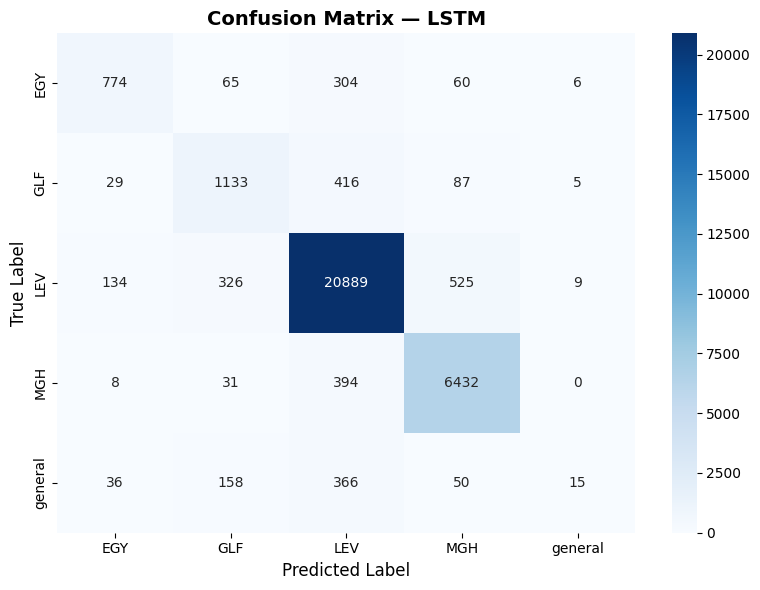

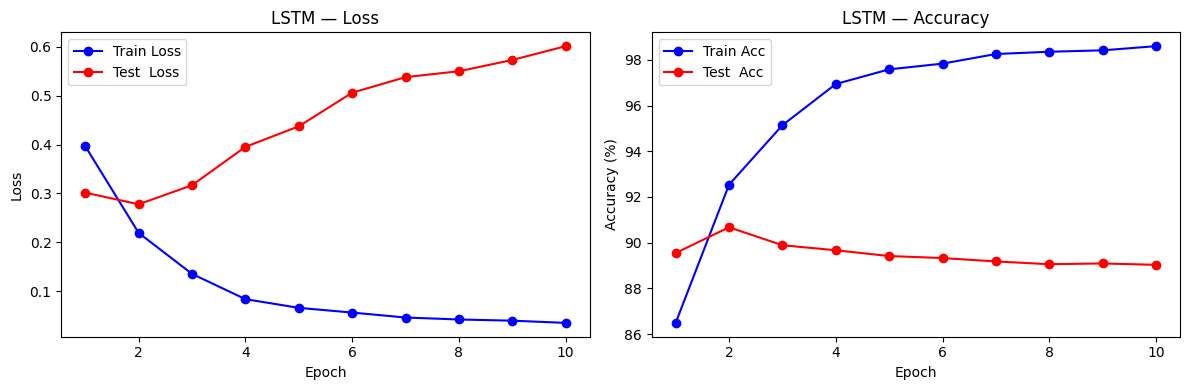

In [23]:
# ─── LSTM ────────────────────────────────────────────────────────
print("\n" + "="*60)
print("  Training LSTM")
print("="*60)

lstm_model = LSTMClassifier(
    embedding_matrix, NUM_CLASSES,
    hidden_size=DL_CONFIG["num_nodes"],
    dropout=DL_CONFIG["dropout"]
)
lstm_model, lstm_history, lstm_preds = train_dl_model(
    lstm_model, train_dl, test_dl,
    epochs=DL_CONFIG["epochs"],
    lr=DL_CONFIG["lr"],
    model_name="LSTM"
)
plot_history(lstm_history, "LSTM")

torch.save(lstm_model.state_dict(), f"{OUTPUT_DIR}/lstm_model.pt")



  Training GRU
Epoch 01/10 | Train Loss: 0.3770 Acc: 87.07% | Test  Loss: 0.2836 Acc: 90.11%
Epoch 02/10 | Train Loss: 0.2042 Acc: 92.96% | Test  Loss: 0.2805 Acc: 90.52%
Epoch 03/10 | Train Loss: 0.1341 Acc: 95.26% | Test  Loss: 0.3396 Acc: 89.71%
Epoch 04/10 | Train Loss: 0.0790 Acc: 97.10% | Test  Loss: 0.4196 Acc: 89.37%
Epoch 05/10 | Train Loss: 0.0632 Acc: 97.62% | Test  Loss: 0.4491 Acc: 89.39%
Epoch 06/10 | Train Loss: 0.0542 Acc: 97.91% | Test  Loss: 0.4955 Acc: 88.81%
Epoch 07/10 | Train Loss: 0.0446 Acc: 98.22% | Test  Loss: 0.5557 Acc: 89.12%
Epoch 08/10 | Train Loss: 0.0415 Acc: 98.35% | Test  Loss: 0.5615 Acc: 89.14%
Epoch 09/10 | Train Loss: 0.0401 Acc: 98.43% | Test  Loss: 0.5846 Acc: 88.91%
Epoch 10/10 | Train Loss: 0.0359 Acc: 98.52% | Test  Loss: 0.6093 Acc: 88.93%

  Model: GRU
  Accuracy : 90.522%
  Precision: 89.620%
  Recall   : 90.522%
  F1-score : 89.702%

              precision    recall  f1-score   support

         EGY       0.78      0.64      0.70      1

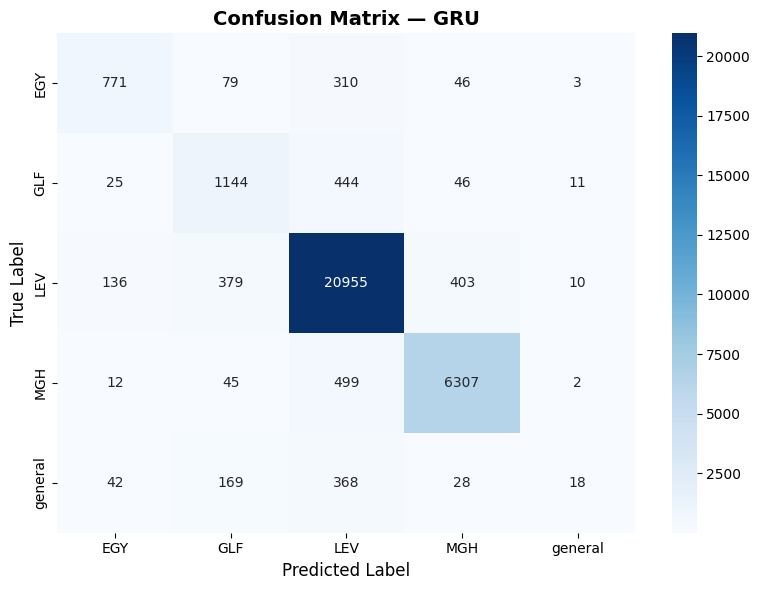

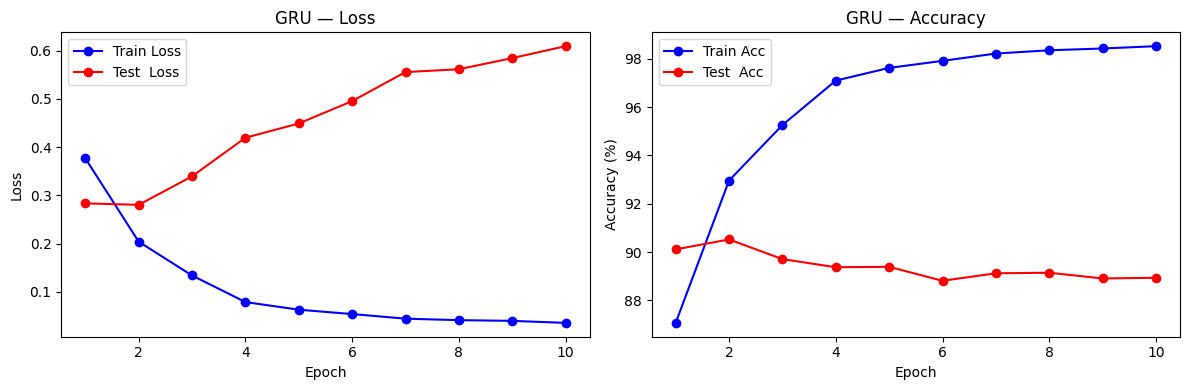

In [24]:
# ─── GRU ─────────────────────────────────────────────────────────
print("\n" + "="*60)
print("  Training GRU")
print("="*60)

gru_model = GRUClassifier(
    embedding_matrix, NUM_CLASSES,
    hidden_size=DL_CONFIG["num_nodes"],
    dropout=DL_CONFIG["dropout"]
)
gru_model, gru_history, gru_preds = train_dl_model(
    gru_model, train_dl, test_dl,
    epochs=DL_CONFIG["epochs"],
    lr=DL_CONFIG["lr"],
    model_name="GRU"
)
plot_history(gru_history, "GRU")

torch.save(gru_model.state_dict(), f"{OUTPUT_DIR}/gru_model.pt")



  Training CNN
Epoch 01/10 | Train Loss: 0.4219 Acc: 85.83% | Test  Loss: 0.3391 Acc: 88.48%
Epoch 02/10 | Train Loss: 0.2620 Acc: 91.25% | Test  Loss: 0.2916 Acc: 90.25%
Epoch 03/10 | Train Loss: 0.1645 Acc: 94.16% | Test  Loss: 0.3318 Acc: 90.11%
Epoch 04/10 | Train Loss: 0.1038 Acc: 96.19% | Test  Loss: 0.3754 Acc: 89.89%
Epoch 05/10 | Train Loss: 0.0820 Acc: 97.02% | Test  Loss: 0.4351 Acc: 89.75%
Epoch 06/10 | Train Loss: 0.0684 Acc: 97.50% | Test  Loss: 0.4743 Acc: 89.32%
Epoch 07/10 | Train Loss: 0.0536 Acc: 97.99% | Test  Loss: 0.5149 Acc: 89.35%
Epoch 08/10 | Train Loss: 0.0483 Acc: 98.18% | Test  Loss: 0.5510 Acc: 89.49%
Epoch 09/10 | Train Loss: 0.0439 Acc: 98.35% | Test  Loss: 0.5766 Acc: 89.38%
Epoch 10/10 | Train Loss: 0.0386 Acc: 98.54% | Test  Loss: 0.5983 Acc: 89.35%

  Model: CNN
  Accuracy : 90.249%
  Precision: 88.833%
  Recall   : 90.249%
  F1-score : 89.235%

              precision    recall  f1-score   support

         EGY       0.79      0.55      0.65      1

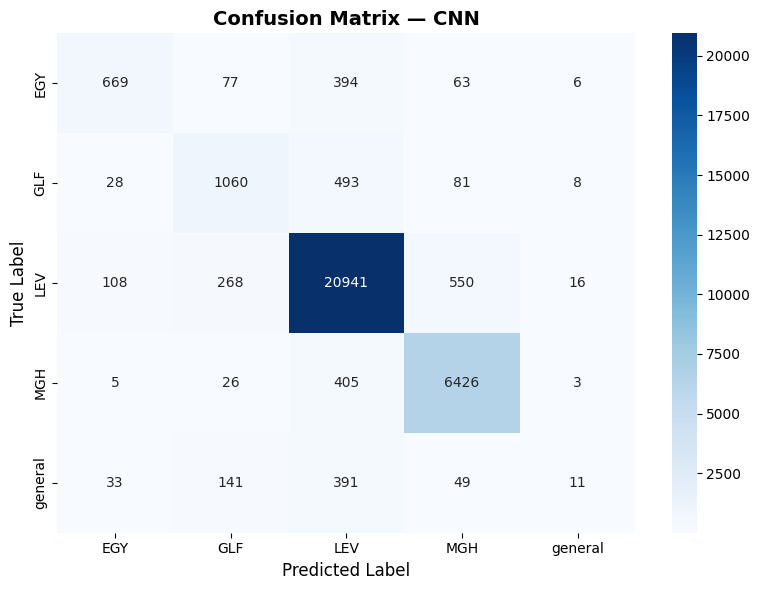

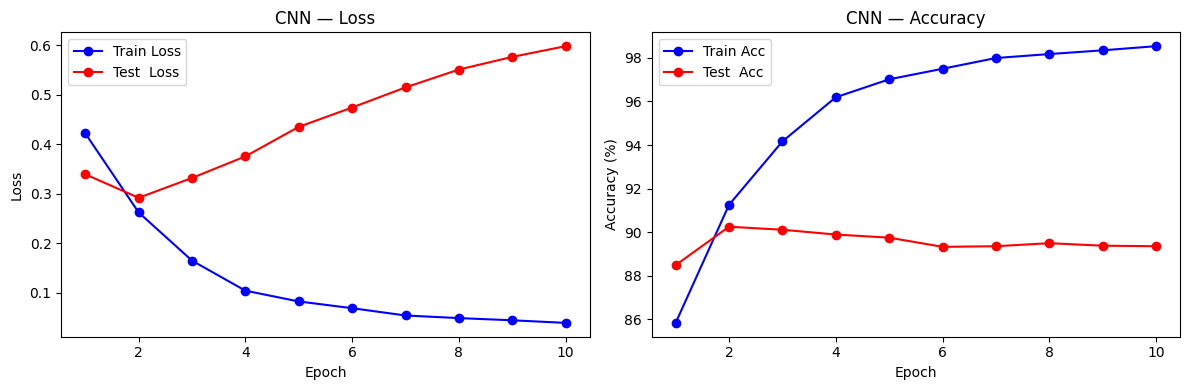

In [25]:
# ─── CNN ─────────────────────────────────────────────────────────
print("\n" + "="*60)
print("  Training CNN")
print("="*60)

cnn_model = CNNClassifier(
    embedding_matrix, NUM_CLASSES,
    num_filters=DL_CONFIG["cnn_filters"],
    kernel_size=DL_CONFIG["kernel_size"],
    dropout=DL_CONFIG["dropout"]
)
cnn_model, cnn_history, cnn_preds = train_dl_model(
    cnn_model, train_dl, test_dl,
    epochs=DL_CONFIG["epochs"],
    lr=DL_CONFIG["lr"],
    model_name="CNN"
)
plot_history(cnn_history, "CNN")

torch.save(cnn_model.state_dict(), f"{OUTPUT_DIR}/cnn_model.pt")


## 14. Transformer Fine-Tuning

### Why transformers outperform classical DL models for Arabic dialects

Recurrent models (LSTM, GRU) process tokens sequentially, which limits their ability to capture long-range dependencies between distant words in a sentence. CNNs detect local n-gram patterns but miss global context.

**Transformer self-attention** computes pairwise attention scores between *every pair of tokens* in the sequence in parallel. This means:
- Any token can directly attend to any other token regardless of distance
- Multi-head attention captures different types of linguistic relationships simultaneously
- The pre-training on massive Arabic corpora gives the model rich morphological and syntactic priors

### Models used

| Model | Pre-training | Dialect awareness |
|-------|-------------|-------------------|
| **Bert-Base-Arabertv02** | 77 GB Arabic text (MSA + dialectal) | Moderate |
| **Dialectal-Arabic-XLM-R-Base** | XLM-R + dialect-specific fine-tuning | High |

### Fine-tuning strategy

We attach a classification head (linear layer → softmax) on top of the `[CLS]` token representation and fine-tune all weights end-to-end using AdamW optimiser with a linear warmup schedule.


In [26]:
class DialectDataset(Dataset):
    """
    HuggingFace-compatible dataset for transformer fine-tuning.
    Tokenises raw Arabic text on the fly using the model's own tokenizer.
    """
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length     = self.max_len,
            padding        = "max_length",
            truncation     = True,
            return_tensors = "pt"
        )
        return {
            "input_ids"     : enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels"        : torch.tensor(self.labels[idx], dtype=torch.long)
        }


def compute_metrics_hf(eval_pred):
    """Metric function for HuggingFace Trainer."""
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc   = accuracy_score(labels, preds)
    f1    = f1_score(labels, preds, average="weighted", zero_division=0)
    return {"accuracy": acc, "f1": f1}

print("Transformer dataset class and metric function defined.")


Transformer dataset class and metric function defined.


In [27]:
def fine_tune_transformer(model_name_hf: str,
                          model_label: str,
                          X_train_data, y_train_data,
                          X_test_data,  y_test_data,
                          config: dict):
    """
    Fine-tune a pretrained transformer for sequence classification.

    Args:
        model_name_hf — HuggingFace model identifier string
        model_label   — human-readable label for logging
        X_train_data  — list of preprocessed training texts
        y_train_data  — list of integer training labels
        X_test_data   — list of preprocessed test texts
        y_test_data   — list of integer test labels
        config        — hyperparameter dict (TRANSFORMER_CONFIG)

    Returns:
        trainer   — HuggingFace Trainer object (fitted)
        tokenizer — model's tokenizer
        preds     — numpy array of test predictions
        probs     — numpy array of softmax probabilities (for stacking)
    """
    print(f"\nLoading tokenizer: {model_name_hf}")
    tokenizer = AutoTokenizer.from_pretrained(model_name_hf)

    print(f"Loading model with {NUM_CLASSES} output labels...")
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name_hf,
        num_labels  = NUM_CLASSES,
        id2label    = id2label,
        label2id    = label_map,
        ignore_mismatched_sizes=True   # allow head replacement
    )

    train_dataset = DialectDataset(X_train_data, y_train_data, tokenizer, config["max_len"])
    test_dataset  = DialectDataset(X_test_data,  y_test_data,  tokenizer, config["max_len"])

    checkpoint_dir = f"{OUTPUT_DIR}/checkpoints/{model_label.replace(' ', '_')}"

    training_args = TrainingArguments(
        output_dir                  = checkpoint_dir,
        num_train_epochs            = config["epochs"],
        per_device_train_batch_size = config["batch_size"],
        per_device_eval_batch_size  = config["batch_size"],
        learning_rate               = config["lr"],
        warmup_steps                = config["warmup_steps"],
        weight_decay                = config["weight_decay"],
        evaluation_strategy         = "epoch",
        save_strategy               = "epoch",
        load_best_model_at_end      = True,
        metric_for_best_model       = "accuracy",
        logging_dir                 = f"{checkpoint_dir}/logs",
        logging_steps               = 100,
        fp16                        = torch.cuda.is_available(),   # mixed precision on GPU
        report_to                   = "none",
        save_safetensors            = False
    )

    trainer = Trainer(
        model           = model,
        args            = training_args,
        train_dataset   = train_dataset,
        eval_dataset    = test_dataset,
        compute_metrics = compute_metrics_hf,
        callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)]
    )

    print(f"\nFine-tuning {model_label}...")
    trainer.train()

    # ── Inference: get logits over test set ─────────────────────
    raw_pred = trainer.predict(test_dataset)
    logits   = raw_pred.predictions
    probs    = torch.softmax(torch.tensor(logits), dim=-1).numpy()
    preds    = np.argmax(logits, axis=-1)

    evaluate_model(model_label, y_test_data, preds)
    plot_confusion_matrix(model_label, y_test_data, preds)

    # ── Also get train set probabilities (needed for stacking) ──
    raw_train = trainer.predict(train_dataset)
    train_probs = torch.softmax(torch.tensor(raw_train.predictions), dim=-1).numpy()

    # Save checkpoint
    trainer.save_model(f"{checkpoint_dir}/best")
    tokenizer.save_pretrained(f"{checkpoint_dir}/best")
    print(f"Saved to {checkpoint_dir}/best")

    return trainer, tokenizer, preds, probs, train_probs

print("fine_tune_transformer() function defined.")


fine_tune_transformer() function defined.



Loading tokenizer: aubmindlab/bert-base-arabertv02


tokenizer_config.json:   0%|          | 0.00/381 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at aubmindlab/bert-base-arabertv02 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Fine-tuning AraBERT...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.316800,0.265344,0.910920,0.903914
2,0.241400,0.257679,0.920222,0.913538
3,0.181100,0.277751,0.918269,0.916027
4,0.135500,0.308399,0.920222,0.918310



  Model: AraBERT
  Accuracy : 92.022%
  Precision: 91.287%
  Recall   : 92.022%
  F1-score : 91.354%

              precision    recall  f1-score   support

         EGY       0.84      0.69      0.75      1209
         GLF       0.76      0.73      0.75      1670
         LEV       0.93      0.97      0.95     21883
         MGH       0.93      0.93      0.93      6865
     general       0.51      0.11      0.18       625

    accuracy                           0.92     32252
   macro avg       0.80      0.69      0.71     32252
weighted avg       0.91      0.92      0.91     32252



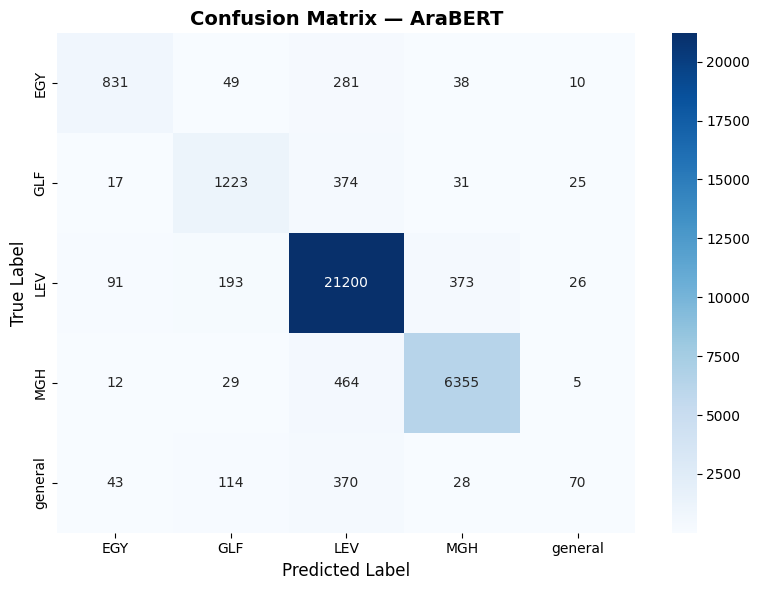

Saved to /kaggle/working/arabic_dialect_stacking/checkpoints/AraBERT/best
AraBERT fine-tuning complete.
Test probs shape (for stacking): (32252, 5)


In [28]:
from tqdm.auto import tqdm

# Initialize tqdm for pandas
tqdm.pandas()

# ─── Fine-tune AraBERT ───────────────────────────────────────────
# Expected runtime: ~25–45 min on a T4 GPU

arabert_trainer, arabert_tokenizer, arabert_test_preds, arabert_test_probs, arabert_train_probs = (
    fine_tune_transformer(
        model_name_hf  = ARABERT_MODEL_NAME,
        model_label    = "AraBERT",
        X_train_data   = X_train,
        y_train_data   = y_train,
        X_test_data    = X_test,
        y_test_data    = y_test,
        config         = TRANSFORMER_CONFIG
    )
)

print("AraBERT fine-tuning complete.")
print(f"Test probs shape (for stacking): {arabert_test_probs.shape}")



Loading tokenizer: CAMeL-Lab/bert-base-arabic-camelbert-da


tokenizer_config.json:   0%|          | 0.00/86.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/468 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/439M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at CAMeL-Lab/bert-base-arabic-camelbert-da and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Fine-tuning XLM-R-Dialectal...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.291900,0.247017,0.919013,0.912173
2,0.184200,0.258372,0.923106,0.918900
3,0.147900,0.331871,0.920656,0.919834
4,0.120600,0.632640,0.919416,0.918657



  Model: XLM-R-Dialectal
  Accuracy : 92.311%
  Precision: 91.769%
  Recall   : 92.311%
  F1-score : 91.890%

              precision    recall  f1-score   support

         EGY       0.77      0.73      0.75      1209
         GLF       0.75      0.79      0.77      1670
         LEV       0.95      0.96      0.95     21883
         MGH       0.92      0.95      0.93      6865
     general       0.48      0.18      0.26       625

    accuracy                           0.92     32252
   macro avg       0.78      0.72      0.73     32252
weighted avg       0.92      0.92      0.92     32252



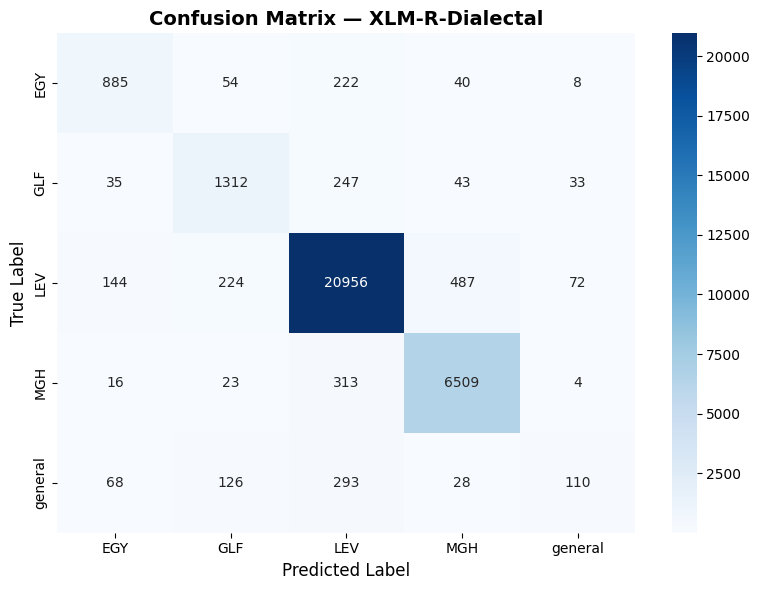

Saved to /kaggle/working/arabic_dialect_stacking/checkpoints/XLM-R-Dialectal/best
XLM-R fine-tuning complete.
Test probs shape (for stacking): (32252, 5)


In [29]:
# ─── Fine-tune Dialectal Arabic XLM-R ────────────────────────────
# NOTE: If rabiaqayyum/xlm-roberta-base-finetuned-arabic-dialect is unavailable,
#       use  XLMR_MODEL_NAME = "CAMeL-Lab/camelbert-da"  as a drop-in replacement.
#       Both are pre-trained on dialectal Arabic.

xlmr_trainer, xlmr_tokenizer, xlmr_test_preds, xlmr_test_probs, xlmr_train_probs = (
    fine_tune_transformer(
        model_name_hf  = XLMR_MODEL_NAME,
        model_label    = "XLM-R-Dialectal",
        X_train_data   = X_train,
        y_train_data   = y_train,
        X_test_data    = X_test,
        y_test_data    = y_test,
        config         = TRANSFORMER_CONFIG
    )
)

print("XLM-R fine-tuning complete.")
print(f"Test probs shape (for stacking): {xlmr_test_probs.shape}")


## 15. 🏆 Stacking Transformer — The Proposed Model

### Core idea

Ensemble learning through **stacking** (Saleh et al. 2025, §3.6):

```
                   ┌─────────────────────────────────────┐
LEVEL 1            │  AraBERT    │   Dialectal-XLM-R     │
(Base Models)      │ [p0..p4]    │   [p0..p4]            │
                   └──────────┬──────────────────────────┘
                              │ concatenate → [p0..p9]
                   ┌──────────▼─────────────────────────┐
LEVEL 2            │       Random Forest (meta-learner)  │
(Meta-Learner)     │  trained on concatenated probs      │
                   └──────────┬──────────────────────────┘
                              │
                        Final prediction
```

**Why this works:**
1. AraBERT and XLM-R are trained on different data distributions and encode complementary linguistic features.
2. The Random Forest sees a richer, 10-dimensional feature space (5 class probs × 2 models) rather than raw text.
3. RF's ensemble of decision trees naturally corrects the individual transformers' systematic errors.

### Data leakage consideration

The meta-learner should ideally be trained on **out-of-fold predictions** (cross-validation) to avoid learning from predictions the base models already "saw". The paper's description implies direct training set probabilities. We implement **both approaches** and note the distinction.


In [30]:
# ─── APPROACH 1 (Paper-faithful): Direct stacking ───────────────
# Use training-set probabilities from both transformers directly.
# This is faster but technically has data leakage in the meta-learner.

print("Building stacking features (direct approach)...")
stacking_train_feats = np.hstack([arabert_train_probs, xlmr_train_probs])
stacking_test_feats  = np.hstack([arabert_test_probs,  xlmr_test_probs])

print(f"Stacking train features shape: {stacking_train_feats.shape}  "
      f"({NUM_CLASSES} AraBERT probs + {NUM_CLASSES} XLM-R probs)")
print(f"Stacking test  features shape: {stacking_test_feats.shape}")

# Show a sample stacking feature vector
print(f"\nSample stacking vector (first test instance):")
print(f"  AraBERT probs  : {arabert_test_probs[0].round(4)}")
print(f"  XLM-R probs    : {xlmr_test_probs[0].round(4)}")
print(f"  Concatenated   : {stacking_test_feats[0].round(4)}")


Building stacking features (direct approach)...
Stacking train features shape: (96754, 10)  (5 AraBERT probs + 5 XLM-R probs)
Stacking test  features shape: (32252, 10)

Sample stacking vector (first test instance):
  AraBERT probs  : [0.000e+00 1.000e-04 9.997e-01 1.000e-04 1.000e-04]
  XLM-R probs    : [1.000e-04 1.000e-04 9.992e-01 5.000e-04 1.000e-04]
  Concatenated   : [0.000e+00 1.000e-04 9.997e-01 1.000e-04 1.000e-04 1.000e-04 1.000e-04
 9.992e-01 5.000e-04 1.000e-04]


Training Random Forest meta-learner...
Random Forest fitted.

  Model: Stacking-Transformer
  Accuracy : 92.338%
  Precision: 92.125%
  Recall   : 92.338%
  F1-score : 92.221%

              precision    recall  f1-score   support

         EGY       0.79      0.73      0.76      1209
         GLF       0.78      0.76      0.77      1670
         LEV       0.95      0.96      0.96     21883
         MGH       0.93      0.95      0.94      6865
     general       0.33      0.29      0.31       625

    accuracy                           0.92     32252
   macro avg       0.76      0.74      0.75     32252
weighted avg       0.92      0.92      0.92     32252



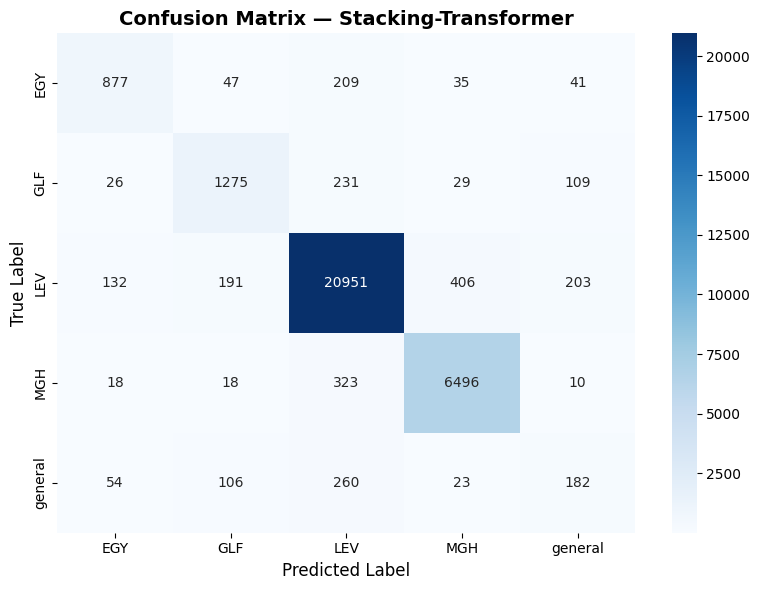

In [31]:
# ─── Train Random Forest meta-learner ───────────────────────────
# RF parameters: default sklearn RF — 100 trees, balanced class weights
# to handle the LEV-dominant imbalance in IADD

print("Training Random Forest meta-learner...")
rf_meta = RandomForestClassifier(
    n_estimators    = 300,
    max_depth       = None,
    class_weight    = "balanced",
    random_state    = SEED,
    n_jobs          = -1,
    verbose         = 0
)
rf_meta.fit(stacking_train_feats, y_train)
print("Random Forest fitted.")

# ── Predict ──────────────────────────────────────────────────────
stacking_preds = rf_meta.predict(stacking_test_feats)
stacking_probs = rf_meta.predict_proba(stacking_test_feats)

evaluate_model("Stacking-Transformer", y_test, stacking_preds)
plot_confusion_matrix("Stacking-Transformer", y_test, stacking_preds)


In [ ]:
# ─── APPROACH 2 (Rigorous): Cross-validated stacking ────────────
# Use 5-fold CV to generate out-of-fold predictions for the training set.
# This eliminates data leakage in the meta-learner.
# NOTE: This requires re-running transformers 5x and is very time-consuming.
#       Uncomment only if you have access to an A100 or multiple GPUs.

# from sklearn.model_selection import StratifiedKFold
#
# kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
# oof_arabert = np.zeros((len(X_train), NUM_CLASSES))
# oof_xlmr    = np.zeros((len(X_train), NUM_CLASSES))
#
# for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train, y_train)):
#     X_tr = [X_train[i] for i in tr_idx]
#     y_tr = [y_train[i] for i in tr_idx]
#     X_val = [X_train[i] for i in val_idx]
#     y_val = [y_train[i] for i in val_idx]
#
#     _, _, _, ab_probs, _ = fine_tune_transformer(ARABERT_MODEL_NAME, f"AraBERT_fold{fold}", ...)
#     oof_arabert[val_idx] = ab_probs
#     ... (similar for XLM-R)
#
# stacking_train_cv = np.hstack([oof_arabert, oof_xlmr])
# rf_cv = RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1)
# rf_cv.fit(stacking_train_cv, y_train)
# cv_preds = rf_cv.predict(stacking_test_feats)

print("Cross-validated stacking code block is available but commented out.")
print("Uncomment and run if you want the leakage-free version.")


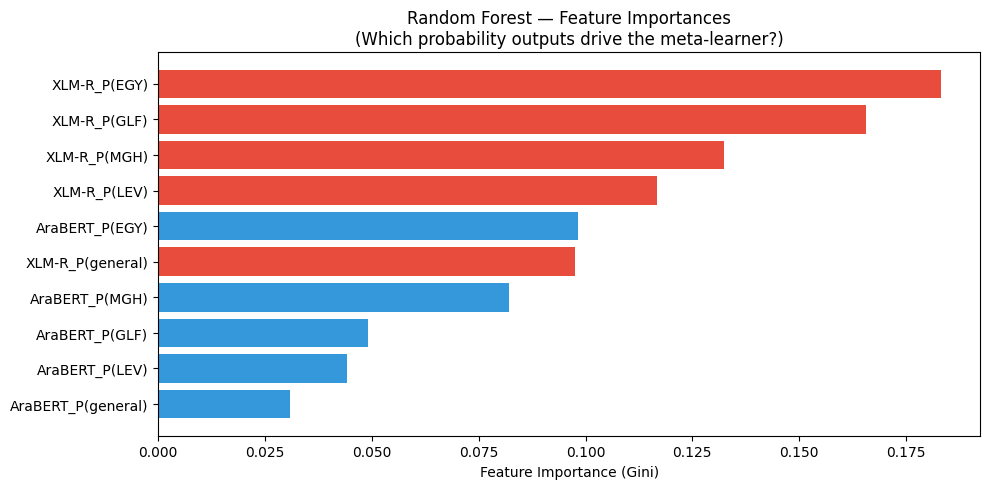

           Feature  Importance
      XLM-R_P(EGY)    0.183155
      XLM-R_P(GLF)    0.165618
      XLM-R_P(MGH)    0.132318
      XLM-R_P(LEV)    0.116780
    AraBERT_P(EGY)    0.098344
  XLM-R_P(general)    0.097596
    AraBERT_P(MGH)    0.082013
    AraBERT_P(GLF)    0.049084
    AraBERT_P(LEV)    0.044271
AraBERT_P(general)    0.030820


In [32]:
# ─── Feature importance from the Random Forest ──────────────────
# Which model's probability outputs does the RF rely on most?

importances = rf_meta.feature_importances_
feature_names = (
    [f"AraBERT_P({id2label[i]})" for i in range(NUM_CLASSES)] +
    [f"XLM-R_P({id2label[i]})"   for i in range(NUM_CLASSES)]
)

importance_df = pd.DataFrame({
    "Feature"   : feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(importance_df["Feature"], importance_df["Importance"],
        color=["#3498db" if "AraBERT" in f else "#e74c3c" for f in importance_df["Feature"]])
ax.set_xlabel("Feature Importance (Gini)")
ax.set_title("Random Forest — Feature Importances\n(Which probability outputs drive the meta-learner?)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/rf_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print(importance_df.to_string(index=False))


## 16. Results Comparison

Compilation of all model results, replicating Table 6 from Saleh et al. (2025).


In [33]:
# ─── Summary table ───────────────────────────────────────────────
results_df = pd.DataFrame(all_results).T.reset_index().rename(columns={"index": "Model"})

# Define model order (weakest → strongest, matching paper ordering)
model_order = ["CNN", "GRU", "LSTM", "AraBERT", "XLM-R-Dialectal", "Stacking-Transformer"]
results_df["Model"] = pd.Categorical(results_df["Model"], categories=model_order, ordered=True)
results_df = results_df.sort_values("Model").reset_index(drop=True)

# Cast to float
for col in ["Accuracy", "Precision", "Recall", "F1-score"]:
    results_df[col] = results_df[col].astype(float)

print("=" * 70)
print("  FULL MODEL COMPARISON — IADD CORPUS")
print("  (Replication of Saleh et al. 2025, Table 5/6)")
print("=" * 70)
print(results_df.to_string(index=False))
print("=" * 70)
print()
best = results_df.loc[results_df["F1-score"].idxmax()]
print(f"Best model: {best['Model']}  |  "
      f"Acc: {best['Accuracy']}%  |  F1: {best['F1-score']}%")


  FULL MODEL COMPARISON — IADD CORPUS
  (Replication of Saleh et al. 2025, Table 5/6)
               Model  Accuracy  Precision  Recall  F1-score
                 CNN    90.249     88.833  90.249    89.235
                 GRU    90.522     89.620  90.522    89.702
                LSTM    90.670     89.711  90.670    89.795
             AraBERT    92.022     91.287  92.022    91.354
     XLM-R-Dialectal    92.311     91.769  92.311    91.890
Stacking-Transformer    92.338     92.125  92.338    92.221

Best model: Stacking-Transformer  |  Acc: 92.338%  |  F1: 92.221%


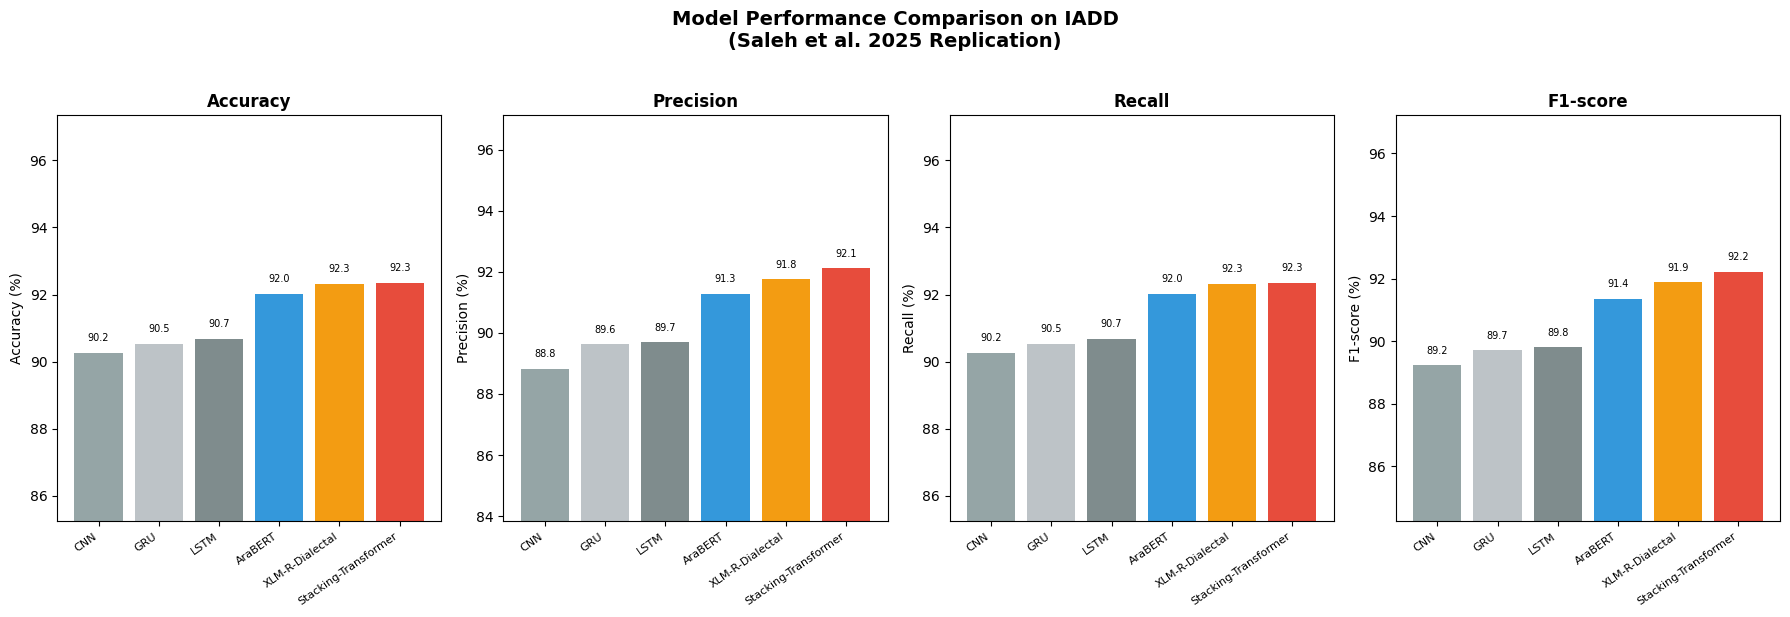

In [34]:
# ─── Bar chart: all metrics across models ───────────────────────
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
colors  = {"CNN": "#95a5a6", "GRU": "#bdc3c7", "LSTM": "#7f8c8d",
           "AraBERT": "#3498db", "XLM-R-Dialectal": "#f39c12",
           "Stacking-Transformer": "#e74c3c"}

fig, axes = plt.subplots(1, 4, figsize=(18, 6), sharey=False)

for ax, metric in zip(axes, metrics):
    models = results_df["Model"].tolist()
    vals   = results_df[metric].tolist()
    bar_colors = [colors.get(m, "grey") for m in models]

    bars = ax.bar(range(len(models)), vals, color=bar_colors)
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=35, ha="right", fontsize=8)
    ax.set_ylabel(f"{metric} (%)", fontsize=10)
    ax.set_title(metric, fontsize=12, fontweight="bold")
    ax.set_ylim(max(0, min(vals) - 5), min(100, max(vals) + 5))

    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f"{val:.1f}", ha="center", va="bottom", fontsize=7)

plt.suptitle("Model Performance Comparison on IADD\n(Saleh et al. 2025 Replication)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/model_comparison_bar.png", dpi=150, bbox_inches="tight")
plt.show()


Per-class F1-score (%) by model:
                        EGY    GLF    LEV    MGH  general
GRU                   70.25  65.63  94.27  92.11     5.38
LSTM                  70.68  66.98  94.41  91.76     4.55
AraBERT               75.44  74.62  95.13  92.84    18.40
XLM-R-Dialectal       75.10  76.97  95.44  93.17    25.82
Stacking-Transformer  75.73  77.11  95.54  93.78    31.11


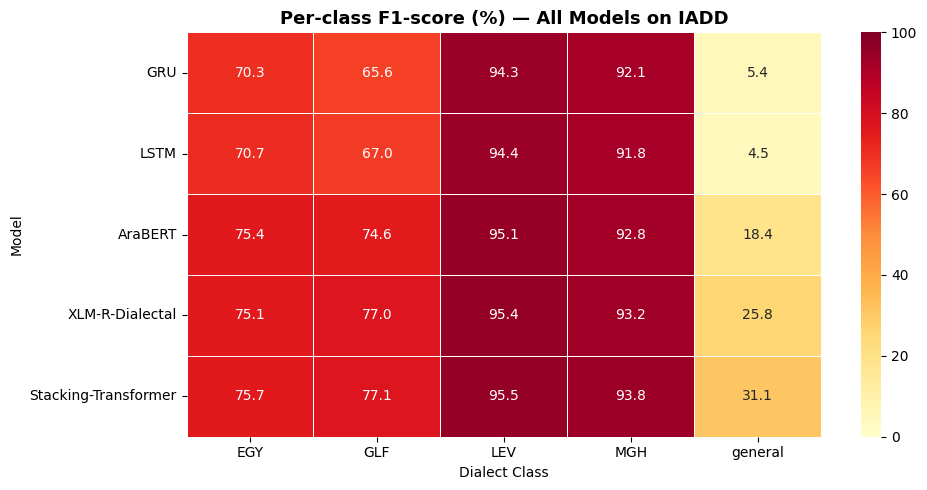

In [35]:
# ─── Radar chart: per-class F1 breakdown ────────────────────────
from matplotlib.patches import FancyArrowPatch

def class_f1_report(model_name, y_true, y_pred):
    rpt = classification_report(y_true, y_pred,
                                target_names=[id2label[i] for i in range(NUM_CLASSES)],
                                output_dict=True, zero_division=0)
    return {cls: rpt[cls]["f1-score"] * 100 for cls in [id2label[i] for i in range(NUM_CLASSES)]}

class_results = {
    "GRU"                  : class_f1_report("GRU",  y_test, gru_preds),
    "LSTM"                 : class_f1_report("LSTM", y_test, lstm_preds),
    "AraBERT"              : class_f1_report("AraBERT", y_test, arabert_test_preds),
    "XLM-R-Dialectal"      : class_f1_report("XLM-R", y_test, xlmr_test_preds),
    "Stacking-Transformer" : class_f1_report("Stack", y_test, stacking_preds),
}

class_df = pd.DataFrame(class_results).T
print("Per-class F1-score (%) by model:")
print(class_df.round(2).to_string())

# Heatmap
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(class_df, annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=0.5, ax=ax, vmin=0, vmax=100)
ax.set_title("Per-class F1-score (%) — All Models on IADD", fontsize=13, fontweight="bold")
ax.set_xlabel("Dialect Class")
ax.set_ylabel("Model")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/perclass_f1_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


In [36]:
# ─── Paper comparison table ──────────────────────────────────────
# Compare against reported numbers from Saleh et al. 2025 (Table 5 & 6)

paper_results = {
    "CNN (paper)"               : {"Accuracy": 87.382, "F1-score": 87.492},
    "GRU (paper)"               : {"Accuracy": 88.0,   "F1-score": 87.9},
    "LSTM (paper)"              : {"Accuracy": 88.0,   "F1-score": 87.9},
    "AraBERT (paper)"           : {"Accuracy": 90.5,   "F1-score": 90.2},
    "XLM-R-Dialectal (paper)"   : {"Accuracy": 91.432, "F1-score": 91.485},
    "Stacking-Transformer (paper)": {"Accuracy": 93.062, "F1-score": 93.184},
}

paper_df = pd.DataFrame(paper_results).T.reset_index().rename(columns={"index": "Model"})
ours_df  = results_df[["Model", "Accuracy", "F1-score"]].copy()
ours_df["Model"] = ours_df["Model"].astype(str) + " (ours)"

comparison = pd.concat([paper_df, ours_df], ignore_index=True)
print("Accuracy and F1 — Paper vs. Our Replication:")
print(comparison.to_string(index=False))


Accuracy and F1 — Paper vs. Our Replication:
                       Model  Accuracy  F1-score
                 CNN (paper)    87.382    87.492
                 GRU (paper)    88.000    87.900
                LSTM (paper)    88.000    87.900
             AraBERT (paper)    90.500    90.200
     XLM-R-Dialectal (paper)    91.432    91.485
Stacking-Transformer (paper)    93.062    93.184
                  CNN (ours)    90.249    89.235
                  GRU (ours)    90.522    89.702
                 LSTM (ours)    90.670    89.795
              AraBERT (ours)    92.022    91.354
      XLM-R-Dialectal (ours)    92.311    91.890
 Stacking-Transformer (ours)    92.338    92.221


## 17. Inference Demo

Run the full stacking pipeline on new raw Arabic text.


In [37]:
def predict_dialect(text: str) -> dict:
    """
    Run the full stacking pipeline on a raw Arabic sentence.

    Steps:
      1. Preprocess the text
      2. Get probability vectors from AraBERT and XLM-R
      3. Concatenate into stacking feature vector
      4. RF meta-learner produces the final dialect prediction

    Returns a dict with the predicted class and confidence per dialect.
    """
    # 1. Preprocess
    clean = preprocess_arabic(text)
    if not clean.strip():
        return {"error": "Empty text after preprocessing."}

    # 2. AraBERT probabilities
    enc_ab = arabert_tokenizer(
        clean, max_length=128, padding="max_length",
        truncation=True, return_tensors="pt"
    )
    enc_ab = {k: v.to(DEVICE) for k, v in enc_ab.items()}

    arabert_model_inf = arabert_trainer.model.eval().to(DEVICE)
    xlmr_model_inf    = xlmr_trainer.model.eval().to(DEVICE)

    with torch.no_grad():
        ab_logits = arabert_model_inf(**enc_ab).logits
        ab_probs  = torch.softmax(ab_logits, dim=-1).cpu().numpy()

    # 3. XLM-R probabilities
    enc_xr = xlmr_tokenizer(
        clean, max_length=128, padding="max_length",
        truncation=True, return_tensors="pt"
    )
    enc_xr = {k: v.to(DEVICE) for k, v in enc_xr.items()}

    with torch.no_grad():
        xr_logits = xlmr_model_inf(**enc_xr).logits
        xr_probs  = torch.softmax(xr_logits, dim=-1).cpu().numpy()

    # 4. Stacking
    stacking_feat = np.hstack([ab_probs, xr_probs])
    rf_probs      = rf_meta.predict_proba(stacking_feat)[0]
    rf_pred_idx   = np.argmax(rf_probs)
    predicted     = id2label[rf_pred_idx]

    return {
        "input_text"         : text[:80],
        "preprocessed"       : clean[:80],
        "arabert_probs"      : {id2label[i]: round(float(ab_probs[0][i]), 4) for i in range(NUM_CLASSES)},
        "xlmr_probs"         : {id2label[i]: round(float(xr_probs[0][i]), 4) for i in range(NUM_CLASSES)},
        "stacking_confidence": {id2label[i]: round(float(rf_probs[i]),    4) for i in range(NUM_CLASSES)},
        "predicted_dialect"  : predicted,
    }


# ─── Test on example sentences ───────────────────────────────────
test_sentences = [
    "وش فيك تسألني إذا كنت غالي ويكثر جنوني",           # Gulf
    "انت بدك تحكي معي هلق مش وقتها",                     # Levantine
    "انت فين يا حبيبي الليلة دي",                         # Egyptian
    "كيفاش تقدر تقول هاد الكلام بالصح",                   # Maghrebi
    "هل الحكومة تستاهل الثقة الجديدة",                   # General/MSA-like
]

for sent in test_sentences:
    result = predict_dialect(sent)
    print(f"Text      : {result['input_text']}")
    print(f"Predicted : {result['predicted_dialect']}")
    print(f"Confidence: {result['stacking_confidence']}")
    print()


Text      : وش فيك تسألني إذا كنت غالي ويكثر جنوني
Predicted : GLF
Confidence: {'EGY': 0.0, 'GLF': 0.9967, 'LEV': 0.0, 'MGH': 0.0033, 'general': 0.0}

Text      : انت بدك تحكي معي هلق مش وقتها
Predicted : LEV
Confidence: {'EGY': 0.0, 'GLF': 0.0, 'LEV': 1.0, 'MGH': 0.0, 'general': 0.0}

Text      : انت فين يا حبيبي الليلة دي
Predicted : EGY
Confidence: {'EGY': 0.8033, 'GLF': 0.0, 'LEV': 0.1933, 'MGH': 0.0, 'general': 0.0033}

Text      : كيفاش تقدر تقول هاد الكلام بالصح
Predicted : MGH
Confidence: {'EGY': 0.0, 'GLF': 0.0, 'LEV': 0.0, 'MGH': 1.0, 'general': 0.0}

Text      : هل الحكومة تستاهل الثقة الجديدة
Predicted : GLF
Confidence: {'EGY': 0.0267, 'GLF': 0.6533, 'LEV': 0.1633, 'MGH': 0.0, 'general': 0.1567}



## 18. Save All Results

In [38]:
import pickle, datetime

# ─── Save results table as CSV ───────────────────────────────────
results_df.to_csv(f"{OUTPUT_DIR}/results_table.csv", index=False)
print("Results saved:", f"{OUTPUT_DIR}/results_table.csv")

# ─── Save RF meta-learner ─────────────────────────────────────────
with open(f"{OUTPUT_DIR}/rf_meta_learner.pkl", "wb") as f:
    pickle.dump(rf_meta, f)
print("RF meta-learner saved.")

# ─── Save stacking features (so you can retrain RF without re-running transformers)
np.save(f"{OUTPUT_DIR}/stacking_train_feats.npy", stacking_train_feats)
np.save(f"{OUTPUT_DIR}/stacking_test_feats.npy",  stacking_test_feats)
np.save(f"{OUTPUT_DIR}/y_train.npy", np.array(y_train))
np.save(f"{OUTPUT_DIR}/y_test.npy",  np.array(y_test))
print("Stacking features saved.")

# ─── Summary log ─────────────────────────────────────────────────
log = {
    "timestamp" : str(datetime.datetime.now()),
    "seed"      : SEED,
    "train_size": len(X_train),
    "test_size" : len(X_test),
    "classes"   : LABEL_NAMES,
    "results"   : all_results,
}
with open(f"{OUTPUT_DIR}/experiment_log.json", "w") as f:
    json.dump(log, f, indent=2)
print("Experiment log saved.")
print()
print("All outputs written to:", OUTPUT_DIR)


Results saved: /kaggle/working/arabic_dialect_stacking/results_table.csv
RF meta-learner saved.
Stacking features saved.
Experiment log saved.

All outputs written to: /kaggle/working/arabic_dialect_stacking


In [42]:
# ─── 1. Export AraBERT and XLM-R Models ─────────────────────────
import os

# Define export paths using the globally defined OUTPUT_DIR
ARABERT_SAVE_PATH = f"{OUTPUT_DIR}/arabert_finetuned"
XLMR_SAVE_PATH = f"{OUTPUT_DIR}/xlmr_finetuned"

os.makedirs(ARABERT_SAVE_PATH, exist_ok=True)
os.makedirs(XLMR_SAVE_PATH, exist_ok=True)

# NOTE: Replace the variable names below (arabert_model, arabert_tokenizer, etc.) 
# with the exact variable names you used in your training cells.

# --- AraBERT Export ---
# If using raw PyTorch / AutoModelForSequenceClassification:
#arabert_model.save_pretrained(ARABERT_SAVE_PATH)
#arabert_tokenizer.save_pretrained(ARABERT_SAVE_PATH)

# If you used HuggingFace Trainer, uncomment the line below instead:
arabert_trainer.save_model(ARABERT_SAVE_PATH)
arabert_tokenizer.save_pretrained(ARABERT_SAVE_PATH)

print(f"AraBERT successfully exported to: {ARABERT_SAVE_PATH}")

# --- XLM-R Export ---
# If using raw PyTorch / AutoModelForSequenceClassification:
#xlmr_model.save_pretrained(XLMR_SAVE_PATH)
#xlmr_tokenizer.save_pretrained(XLMR_SAVE_PATH)

# If you used HuggingFace Trainer, uncomment the line below instead:
xlmr_trainer.save_model(XLMR_SAVE_PATH)
xlmr_tokenizer.save_pretrained(XLMR_SAVE_PATH)

print(f"XLM-R successfully exported to: {XLMR_SAVE_PATH}")

AraBERT successfully exported to: /kaggle/working/arabic_dialect_stacking/arabert_finetuned
XLM-R successfully exported to: /kaggle/working/arabic_dialect_stacking/xlmr_finetuned


In [43]:
# ─── 2. Zip the Models for Easy Download ────────────────────────
import shutil

print("Zipping models for export...")

# Create zip files for both models so your friend can easily download them from Kaggle
shutil.make_archive(f"{OUTPUT_DIR}/arabert_finetuned", 'zip', ARABERT_SAVE_PATH)
shutil.make_archive(f"{OUTPUT_DIR}/xlmr_finetuned", 'zip', XLMR_SAVE_PATH)

print("Zip complete! You can download the following files from your Kaggle '/working' directory:")
print(f"1. {OUTPUT_DIR}/arabert_finetuned.zip")
print(f"2. {OUTPUT_DIR}/xlmr_finetuned.zip")

Zipping models for export...
Zip complete! You can download the following files from your Kaggle '/working' directory:
1. /kaggle/working/arabic_dialect_stacking/arabert_finetuned.zip
2. /kaggle/working/arabic_dialect_stacking/xlmr_finetuned.zip
